# Flight Delay and Overbooking Prediction

## Data Preparation

**All data files have already been prepared and saved to the `data` folder. This section explains what was done.**


Two datasets were combined to build the training data:

- **Flight delay data** (`full_data_flightdelay.csv`): ~6.5M US domestic flights from 2019. Contains the delay target (`DEP_DEL15`) and flight/weather features.
- **booking data** (`flight_bookings.csv`): ~366k simulated flight records public SFO passenger statistics, containing seat counts, passenger counts, load factors, and an overbooking label.

**These two datasets were merged on: airline name + month.**

Before joining, carrier names were normalized lowercased and stripped of punctuation and legal suffixes such as Inc., Co., Ltd. so names like `Delta Air Lines Inc.` and `Delta Air Lines` would match correctly. The bookings data was then aggregated per (airline, month), computing average load factor, average passengers, and overbooking rate, and left-joined onto the delay sample.

81.4% of rows found a match. The remaining 18.6% (carriers not in the SFO dataset, e.g. United, Spirit) have NaN for booking columns and will be imputed before training.

**Output:** `merged_flights.csv` -- 10,000 rows x 30 columns.

## Loading the Dataset

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/merged_flights.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (10000, 30)
Columns: ['MONTH', 'DAY_OF_WEEK', 'DEP_DEL15', 'DEP_TIME_BLK', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'CARRIER_NAME', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'DEPARTING_AIRPORT', 'LATITUDE', 'LONGITUDE', 'PREVIOUS_AIRPORT', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND', 'avg_load_factor', 'avg_passengers', 'overbooked_rate', 'avg_seats_booked']


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,avg_load_factor,avg_passengers,overbooked_rate,avg_seats_booked
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,...,NONE,0.0,0.0,0.0,65.0,2.91,0.8851,126.540741,0.1704,143.0
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,...,NONE,0.0,0.0,0.0,65.0,2.91,0.8050,128.805882,0.0553,160.0
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,...,NONE,0.0,0.0,0.0,65.0,2.91,0.8050,128.805882,0.0553,160.0
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,...,NONE,0.0,0.0,0.0,65.0,2.91,0.8050,128.805882,0.0553,160.0
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,...,NONE,0.0,0.0,0.0,65.0,2.91,NaN,NaN,NaN,NaN


In [7]:
print("=== Dataset Summary ===")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print("\n--- Delay Target (DEP_DEL15) ---")
print(df["DEP_DEL15"].value_counts(normalize=True).round(3))
print("\n--- Booking Feature Coverage ---")
booking_cols = ["avg_load_factor", "avg_passengers", "overbooked_rate", "avg_seats_booked"]
print(df[booking_cols].notna().mean().round(3))
print("\n--- Null counts (columns with nulls only) ---")
nulls = df.isnull().sum()
print(nulls[nulls > 0])

=== Dataset Summary ===
Total rows: 10,000
Total columns: 30

--- Delay Target (DEP_DEL15) ---
DEP_DEL15
0    0.833
1    0.167
Name: proportion, dtype: float64

--- Booking Feature Coverage ---
avg_load_factor     0.814
avg_passengers      0.814
overbooked_rate     0.814
avg_seats_booked    0.814
dtype: float64

--- Null counts (columns with nulls only) ---
avg_load_factor     1857
avg_passengers      1857
overbooked_rate     1857
avg_seats_booked    1857
dtype: int64


## ASRS LLM Risk Score Feature
This section adds an optional feature derived from the **Aviation Safety Reporting System (ASRS)** dataset. ASRS collects voluntary incident reports submitted by pilots, controllers, and crew each containing a free-text narrative describing a safety-related event.

### Concept
Each incident report is passed through an LLM which returns a **risk score between 0 and 1** reflecting how likely the described event is to contribute to a flight delay. Scores are aggregated by airport and month, then merged into the main dataset. Flights with no matching ASRS report are assigned a score of **0** (no incident reported).

### Merge key
The ASRS score is joined onto the delay dataset using:
- `DEPARTING_AIRPORT` -- departure airport name
- `MONTH` -- month of the flight (1-12)

When multiple reports exist for the same airport+month, their scores are averaged.

In [8]:
from transformers import pipeline

scorer = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

CANDIDATE_LABELS = [
    "likely to cause a flight delay",
    "unlikely to cause a flight delay"
]

def score_narrative(text):
    """Return delay risk score (0-1) for a single ASRS narrative."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    result = scorer(text[:512], candidate_labels=CANDIDATE_LABELS)
    return round(result["scores"][0], 4)

print("LLM scorer loaded.")

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 6274.99it/s]


LLM scorer loaded.


### Load and Score ASRS Reports

In [ ]:
df_asrs_raw = pd.read_csv("../data/ASRS_DBOnline.csv", header=[0, 1])

df_asrs = pd.DataFrame({
    "date":      df_asrs_raw[("Time",  "Date")],
    "locale":    df_asrs_raw[("Place", "Locale Reference")],
    "narrative": df_asrs_raw[("Report 1", "Narrative")],
})

df_asrs["month"] = df_asrs["date"].astype(str).str[-2:].astype(int)
df_asrs["airport_code"] = df_asrs["locale"].astype(str).str.split(".").str[0]
df_asrs = df_asrs[df_asrs["airport_code"] != "ZZZ"].copy()

print(f"Usable ASRS records (known airport): {len(df_asrs)}")
print("Airport codes found:", df_asrs["airport_code"].unique().tolist())

df_asrs["risk_score"] = df_asrs["narrative"].apply(score_narrative)

CODE_TO_NAME = {
    "SFO": "San Francisco International",
    "LAX": "Los Angeles International",
    "ORD": "Chicago O Hare International",
    "ATL": "Atlanta Municipal",
    "DEN": "Denver International",
    "DFW": "Dallas/Fort Worth International",
    "JFK": "John F Kennedy International",
    "LAS": "McCarran International",
    "MCO": "Orlando International",
    "SEA": "Seattle-Tacoma International",
    "CTY": "Cross City",
    "X04": "Lake Wales Municipal",
}
df_asrs["DEPARTING_AIRPORT"] = df_asrs["airport_code"].map(CODE_TO_NAME)
df_asrs = df_asrs.dropna(subset=["DEPARTING_AIRPORT"])
df_asrs["MONTH"] = df_asrs["month"]

# Aggregate: mean risk score per airport and month
asrs_agg = (
    df_asrs
    .groupby(["DEPARTING_AIRPORT", "MONTH"])["risk_score"]
    .mean()
    .reset_index()
    .rename(columns={"risk_score": "asrs_risk_score"})
)
asrs_agg["asrs_risk_score"] = asrs_agg["asrs_risk_score"].round(4)

# Left join onto main dataset; unmatched flights get score 0
df = df.merge(asrs_agg, on=["DEPARTING_AIRPORT", "MONTH"], how="left")
df["asrs_risk_score"] = df["asrs_risk_score"].fillna(0.0)

print(f"asrs_risk_score column added.")
print(f"Non-zero entries: {(df['asrs_risk_score'] > 0).sum()} / {len(df)}")
print(df["asrs_risk_score"].describe().round(4))


Usable ASRS records (known airport): 1838
Airport codes found: ['SFO', nan, 'X04', 'CTY', 'YBBB', 'ZMP', 'SUW', 'FAT', 'EWR', 'HCF', 'ZZZZ', 'MHCC', 'FWA', 'ORD', 'LTAA', 'TYS', 'LGA', 'EPWW', 'FLL', 'AVQ', 'IND', 'ABQ', 'RKRR', 'MIA', 'HOU', 'VYYF', 'SAC', 'SNS', 'AFW', 'HWD', 'ABE', 'BHM', 'IAH', 'PHZH', 'D01', 'IAD', 'GWO', 'L30', 'DEN', 'DED', 'GEG', 'ZLC', 'SCT', 'LTBB', 'ZGGG', 'RSW', 'IMB', 'CHO', 'THA', 'LAF', 'ASE', 'SQL', 'TCY', 'LBSR', 'NCT', 'ZFW', 'ZBPE', 'DAL', 'SPK', 'FXE', 'PHL', 'SYR', '24J', 'LMO', 'STT', 'BFL', 'ZKC', 'JAC', 'CLT', 'PSF', 'PQL', '79C', 'TJIG', 'SZP', 'LGB', 'RDM', 'MMMM', 'TTN', 'CVO', '3G3', 'ZGSZ', 'MRY', 'TRM', 'ZDC', 'DFW', 'TUS', 'SEA', 'OEB', 'JLN', 'ZMA', 'RUQ', 'PHX', 'SMO', 'PCM', 'VNY', 'MMHO', 'AXH', 'BWI', 'APA', 'JFK', 'CSG', 'D57', 'AFJ', 'Y90', 'LAX', 'UKFV', 'GYR', 'LEB', 'B18', 'CZWG', 'OPF', 'LBB', 'MOB', 'MTJ', 'ANC', 'DCA', 'AUS', 'ZLA', 'PGV', 'EGGX', 'ROA', 'SJC', 'ZPKM', 'MMPR', 'GAI', 'CHD', 'ZDV', 'PMP', 'X26', 'LAS', 'LTFM',

## 3. Flight Delay Prediction

A **Multilayer Perceptron (MLP)** trained on `merged_flights.csv` predicts `DEP_DEL15` (1 = delayed >= 15 min, 0 = on time).

**Architecture:** Linear(128) → ReLU → Dropout(0.3) → Linear(64) → ReLU → Dropout(0.3) → Linear(32) → ReLU → Linear(1)  
**Loss:** BCEWithLogitsLoss with positive-class weight to handle class imbalance  
**Optimizer:** Adam (lr=1e-3, weight_decay=1e-4), early stopping (patience=8)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay,
)

NUM_COLS = [
    "MONTH", "DAY_OF_WEEK", "DISTANCE_GROUP", "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS", "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH", "AIRLINE_FLIGHTS_MONTH", "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT", "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS", "GROUND_SERV_PER_PASS",
    "PLANE_AGE", "LATITUDE", "LONGITUDE",
    "PRCP", "SNOW", "SNWD", "TMAX", "AWND",
    "avg_load_factor", "avg_passengers", "overbooked_rate",
    "avg_seats_booked", "asrs_risk_score",
]
CAT_COLS = ["CARRIER_NAME", "DEP_TIME_BLK", "DEPARTING_AIRPORT"]
TARGET   = "DEP_DEL15"

df_delay = df.copy()

# Impute missing booking columns (18.6% of rows) with column mean
for col in ["avg_load_factor", "avg_passengers", "overbooked_rate", "avg_seats_booked"]:
    df_delay[col] = df_delay[col].fillna(df_delay[col].mean())

# If ASRS cell was skipped, add a zero column so the pipeline still works
if "asrs_risk_score" not in df_delay.columns:
    df_delay["asrs_risk_score"] = 0.0

# One-hot encode categoricals
df_delay = pd.get_dummies(df_delay, columns=CAT_COLS, drop_first=True, dtype=float)

ohe_cols = [c for c in df_delay.columns
            if any(c.startswith(p + "_") for p in CAT_COLS)]
feature_cols_delay = [c for c in NUM_COLS if c in df_delay.columns] + ohe_cols

X = df_delay[feature_cols_delay].astype(float).values
y = df_delay[TARGET].values.astype(float)

scaler_delay = StandardScaler()
X = scaler_delay.fit_transform(X)

# 70 / 15 / 15 train / val / test split (stratified)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print(f"Train: {X_tr.shape}  Val: {X_val.shape}  Test: {X_te.shape}")
print(f"Delay rate  ->  train: {y_tr.mean():.3f}  |  test: {y_te.mean():.3f}")
print(f"Input dimension: {X_tr.shape[1]}")

Train: (7000, 89)  Val: (1500, 89)  Test: (1500, 89)
Delay rate  ->  train: 0.167  |  test: 0.167
Input dimension: 89


Training Flight Delay MLP...
  Epoch  10  val_loss=0.9723
  Early stop @ epoch 15  (best val_loss=0.9588)

=== Flight Delay MLP ===
              precision    recall  f1-score   support

    No Delay     0.9135    0.7856    0.8447      1250
     Delayed     0.3694    0.6280    0.4652       250

    accuracy                         0.7593      1500
   macro avg     0.6415    0.7068    0.6550      1500
weighted avg     0.8228    0.7593    0.7815      1500

ROC-AUC: 0.7713


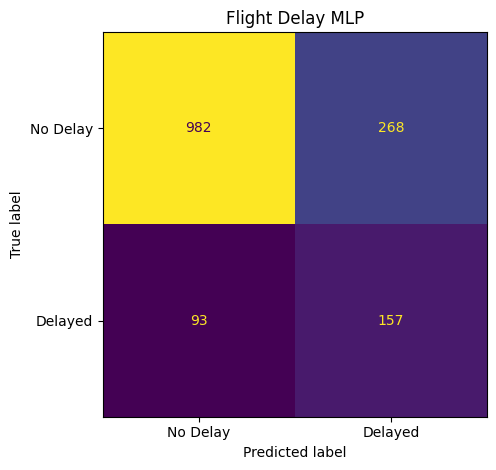

In [15]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


def train_mlp(X_tr, y_tr, X_val, y_val,
              epochs=80, patience=8, lr=1e-3, batch_size=256):
    model = MLP(X_tr.shape[1])
    pos_w = torch.tensor([(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)],
                         dtype=torch.float32)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    Xt = torch.tensor(X_tr,  dtype=torch.float32)
    yt = torch.tensor(y_tr,  dtype=torch.float32)
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32)

    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
    best_loss, no_improve, best_state = float("inf"), 0, None

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = crit(model(Xv), yv).item()

        if val_loss < best_loss - 1e-6:
            best_loss, no_improve = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop @ epoch {epoch}  (best val_loss={best_loss:.4f})")
                break
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}  val_loss={val_loss:.4f}")

    model.load_state_dict(best_state)
    return model


def evaluate_model(model, X_te, y_te, title=""):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_te, dtype=torch.float32))
        probs  = torch.sigmoid(logits).numpy()
    preds = (probs >= 0.5).astype(int)

    print(f"\n=== {title} ===")
    print(classification_report(y_te.astype(int), preds,
                                target_names=["No Delay", "Delayed"], digits=4))
    print(f"ROC-AUC: {roc_auc_score(y_te, probs):.4f}")

    cm = confusion_matrix(y_te.astype(int), preds)
    ConfusionMatrixDisplay(cm, display_labels=["No Delay", "Delayed"]).plot(colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return probs


print("Training Flight Delay MLP...")
model_delay = train_mlp(X_tr, y_tr, X_val, y_val)
_ = evaluate_model(model_delay, X_te, y_te, title="Flight Delay MLP")

## 4. Overbooking Prediction

A second MLP is trained on `flight_bookings.csv` to predict `overbooked` (1 = flight overbooked).  
The same architecture and training loop from Section 3 are reused. Features come from SFO monthly booking statistics.

In [17]:
df_book = pd.read_csv("../data/flight_bookings.csv")
print(f"Bookings shape: {df_book.shape}")
print(df_book["overbooked"].value_counts(normalize=True).round(3))

NUM_OB    = ["month", "seats", "passengers", "load_factor"]
CAT_OB    = ["airline", "geo_summary", "geo_region", "terminal", "price_category"]
TARGET_OB = "overbooked"

df_b = df_book.copy()
# month column contains full names (e.g. "July") -- convert to integers 1-12
MONTH_MAP = {"January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
             "July":7,"August":8,"September":9,"October":10,"November":11,"December":12}
df_b["month"] = df_b["month"].map(MONTH_MAP)
df_b = pd.get_dummies(df_b, columns=CAT_OB, drop_first=True, dtype=float)

ohe_ob = [c for c in df_b.columns
          if any(c.startswith(p + "_") for p in CAT_OB)]
feature_cols_ob = [c for c in NUM_OB if c in df_b.columns] + ohe_ob

X_ob = df_b[feature_cols_ob].astype(float).values
y_ob = df_b[TARGET_OB].values.astype(float)

scaler_ob = StandardScaler()
X_ob = scaler_ob.fit_transform(X_ob)

X_tr_ob, X_tmp_ob, y_tr_ob, y_tmp_ob = train_test_split(
    X_ob, y_ob, test_size=0.30, random_state=42, stratify=y_ob)
X_val_ob, X_te_ob, y_val_ob, y_te_ob = train_test_split(
    X_tmp_ob, y_tmp_ob, test_size=0.50, random_state=42, stratify=y_tmp_ob)

print(f"Train: {X_tr_ob.shape}  Val: {X_val_ob.shape}  Test: {X_te_ob.shape}")
print(f"Overbooked rate  ->  train: {y_tr_ob.mean():.3f}  |  test: {y_te_ob.mean():.3f}")
print(f"Input dimension: {X_tr_ob.shape[1]}")

Bookings shape: (366716, 12)
overbooked
0    0.941
1    0.059
Name: proportion, dtype: float64
Train: (256701, 92)  Val: (55007, 92)  Test: (55008, 92)
Overbooked rate  ->  train: 0.059  |  test: 0.059
Input dimension: 92


Training Overbooking MLP...
  Epoch  10  val_loss=0.0225
  Epoch  20  val_loss=0.0244
  Early stop @ epoch 21  (best val_loss=0.0218)

=== Overbooking MLP ===
              precision    recall  f1-score   support

    No Delay     1.0000    0.9933    0.9967     51788
     Delayed     0.9032    1.0000    0.9492      3220

    accuracy                         0.9937     55008
   macro avg     0.9516    0.9967    0.9729     55008
weighted avg     0.9943    0.9937    0.9939     55008

ROC-AUC: 0.9999


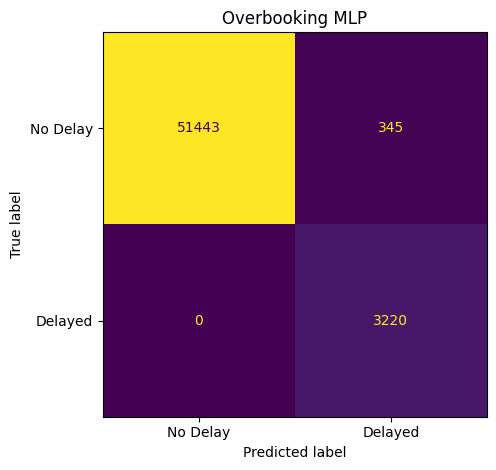

In [18]:
print("Training Overbooking MLP...")
model_ob = train_mlp(X_tr_ob, y_tr_ob, X_val_ob, y_val_ob, batch_size=1024)
_ = evaluate_model(model_ob, X_te_ob, y_te_ob, title="Overbooking MLP")

## 5. Extended Evaluation

Additional diagnostics for both models:
- **ROC curves** -- trade-off between true positive rate and false positive rate at all thresholds
- **Precision-Recall curves** -- especially informative for the imbalanced delay dataset (~20% positive)
- **Threshold sweep** -- find the decision threshold that maximises F1 on the test set
- **Permutation feature importance** -- which features matter most for each model

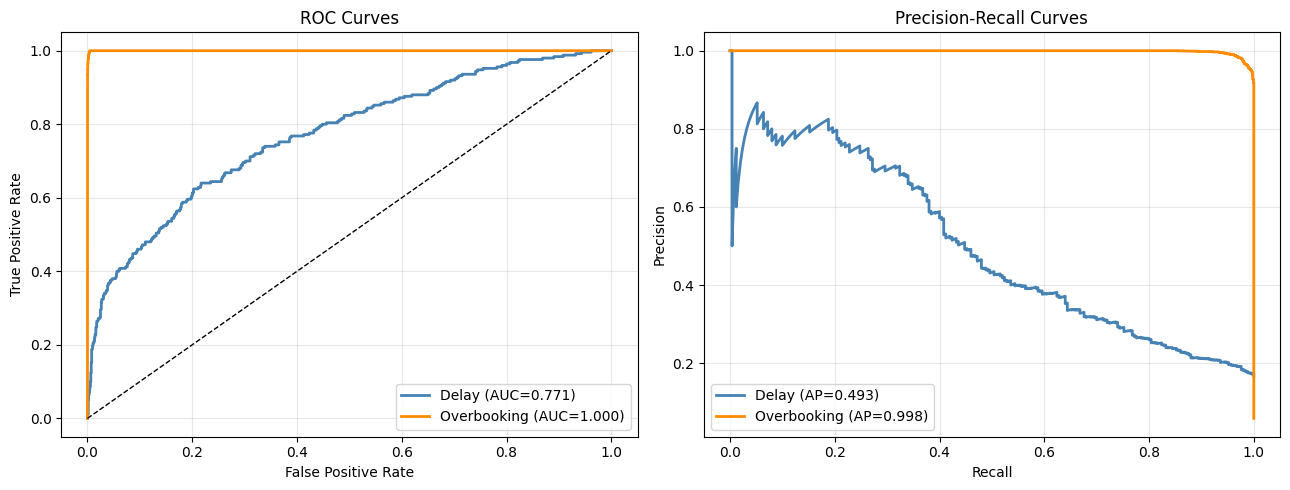

In [19]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

def get_probs(model, X):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(X, dtype=torch.float32))).numpy()

probs_delay = get_probs(model_delay, X_te)
probs_ob    = get_probs(model_ob,    X_te_ob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC ──
for (probs, y_true, label, color) in [
    (probs_delay, y_te,    "Delay (AUC={:.3f})".format(roc_auc_score(y_te,    probs_delay)), "steelblue"),
    (probs_ob,    y_te_ob, "Overbooking (AUC={:.3f})".format(roc_auc_score(y_te_ob, probs_ob)), "darkorange"),
]:
    fpr, tpr, _ = roc_curve(y_true, probs)
    axes[0].plot(fpr, tpr, label=label, color=color, lw=2)
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend(); axes[0].grid(alpha=0.3)

# ── Precision-Recall ──
for (probs, y_true, label, color) in [
    (probs_delay, y_te,    "Delay", "steelblue"),
    (probs_ob,    y_te_ob, "Overbooking", "darkorange"),
]:
    prec, rec, _ = precision_recall_curve(y_true, probs)
    axes[1].plot(rec, prec, label=f"{label} (AP={auc(rec,prec):.3f})", color=color, lw=2)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

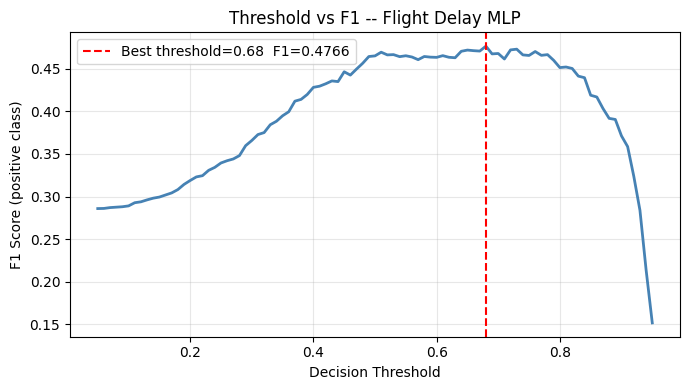

Flight Delay MLP: best threshold=0.68, F1=0.4766
              precision    recall  f1-score   support

    No Delay     0.8922    0.9136    0.9028      1250
     Delayed     0.5091    0.4480    0.4766       250

    accuracy                         0.8360      1500
   macro avg     0.7006    0.6808    0.6897      1500
weighted avg     0.8283    0.8360    0.8317      1500



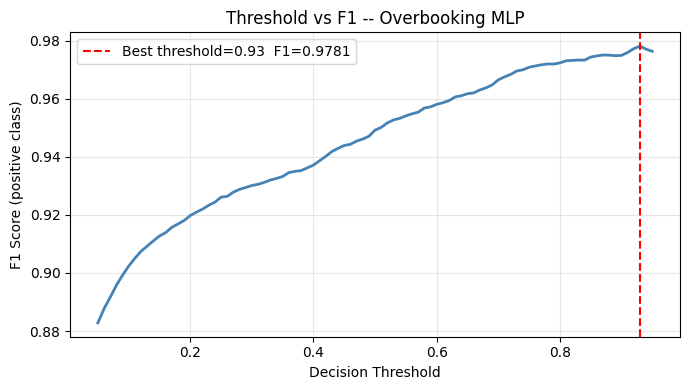

Overbooking MLP: best threshold=0.93, F1=0.9781
              precision    recall  f1-score   support

    No Delay     0.9985    0.9987    0.9986     51788
     Delayed     0.9797    0.9764    0.9781      3220

    accuracy                         0.9974     55008
   macro avg     0.9891    0.9876    0.9884     55008
weighted avg     0.9974    0.9974    0.9974     55008



In [20]:
from sklearn.metrics import f1_score

def threshold_sweep(probs, y_true, title):
    thresholds = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_true.astype(int), (probs >= t).astype(int), zero_division=0)
           for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    best_f1 = max(f1s)

    plt.figure(figsize=(7, 4))
    plt.plot(thresholds, f1s, lw=2, color="steelblue")
    plt.axvline(best_t, color="red", linestyle="--",
                label=f"Best threshold={best_t:.2f}  F1={best_f1:.4f}")
    plt.xlabel("Decision Threshold"); plt.ylabel("F1 Score (positive class)")
    plt.title(f"Threshold vs F1 -- {title}"); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"{title}: best threshold={best_t:.2f}, F1={best_f1:.4f}")
    preds_opt = (probs >= best_t).astype(int)
    print(classification_report(y_true.astype(int), preds_opt,
                                target_names=["No Delay", "Delayed"], digits=4))

threshold_sweep(probs_delay, y_te,    "Flight Delay MLP")
threshold_sweep(probs_ob,    y_te_ob, "Overbooking MLP")

Computing permutation importance for Delay model...


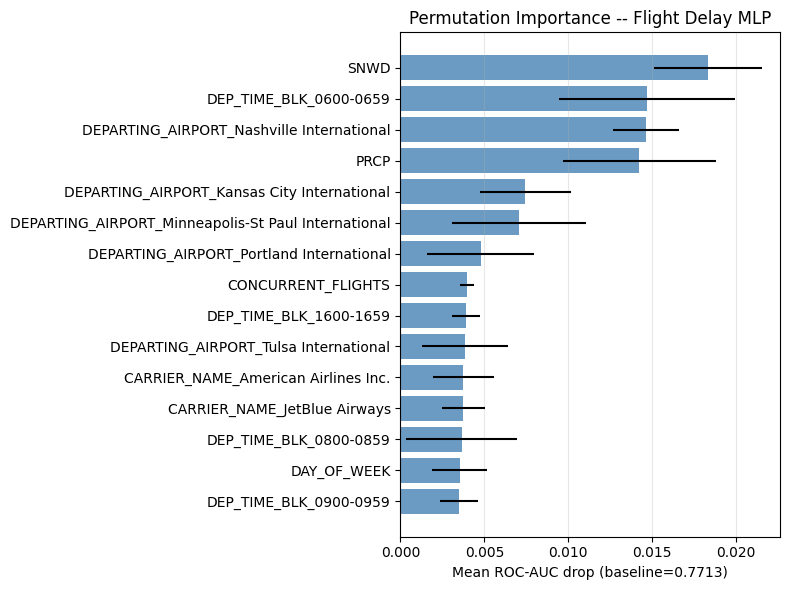

Computing permutation importance for Overbooking model...


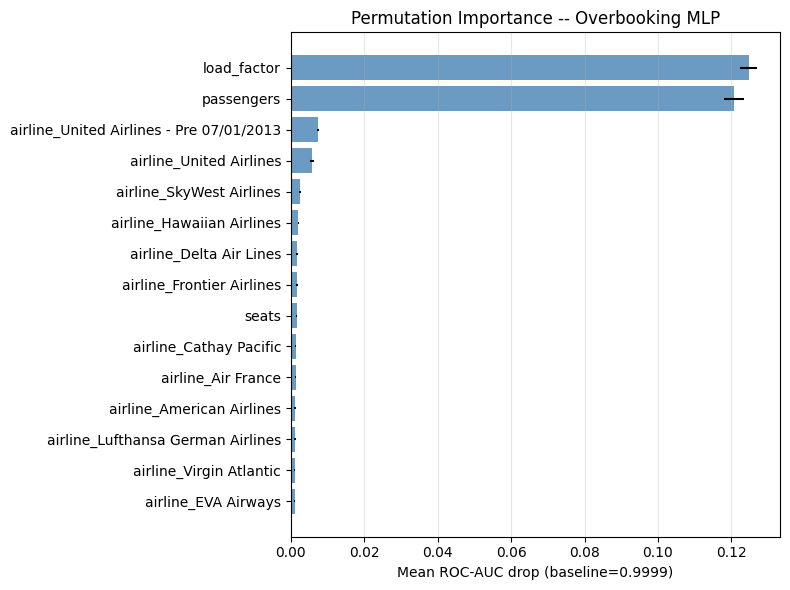

In [23]:
def permutation_importance_manual(model, X_te, y_te, feature_names, title, top_n=15, n_repeats=8):
    """Manual permutation importance: drop in ROC-AUC when each feature is shuffled."""
    model.eval()
    def get_auc(X):
        with torch.no_grad():
            p = torch.sigmoid(model(torch.tensor(X, dtype=torch.float32))).numpy()
        return roc_auc_score(y_te, p)

    baseline = get_auc(X_te)
    means, stds = [], []
    rng = np.random.default_rng(42)

    for j in range(X_te.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_perm = X_te.copy()
            rng.shuffle(X_perm[:, j])
            drops.append(baseline - get_auc(X_perm))
        means.append(np.mean(drops))
        stds.append(np.std(drops))

    means, stds = np.array(means), np.array(stds)
    idx = np.argsort(means)[-top_n:]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(np.array(feature_names)[idx], means[idx],
            xerr=stds[idx], color="steelblue", alpha=0.8)
    ax.set_xlabel("Mean ROC-AUC drop (baseline={:.4f})".format(baseline))
    ax.set_title(f"Permutation Importance -- {title}")
    ax.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

print("Computing permutation importance for Delay model...")
permutation_importance_manual(model_delay, X_te,    y_te,    feature_cols_delay, "Flight Delay MLP")

print("Computing permutation importance for Overbooking model...")
permutation_importance_manual(model_ob,    X_te_ob, y_te_ob, feature_cols_ob,    "Overbooking MLP")

In [ ]:
import pickle, os
os.makedirs('../webapp/models', exist_ok=True)

# Save PyTorch model weights
import torch
torch.save(model_delay.state_dict(), '../webapp/models/model_delay.pt')
torch.save(model_ob.state_dict(),    '../webapp/models/model_ob.pt')

# Save input dimensions (needed to reconstruct models)
import json as _json
meta = {
    'delay_input_dim':  int(X_tr.shape[1]),
    'ob_input_dim':     int(X_tr_ob.shape[1]),
    'feature_cols_delay': feature_cols_delay,
    'feature_cols_ob':    feature_cols_ob,
}
with open('../webapp/models/meta.json', 'w') as f:
    _json.dump(meta, f)

# Save scalers
import pickle
with open('../webapp/models/scaler_delay.pkl', 'wb') as f:
    pickle.dump(scaler_delay, f)
with open('../webapp/models/scaler_ob.pkl', 'wb') as f:
    pickle.dump(scaler_ob, f)

print('Models and scalers exported to webapp/models/')


Models and scalers exported to webapp/models/


: 